> **🤖 AI-assisted.** This notebook is part of an **AI-assisted extension of [Dynestyx](https://github.com/BasisResearch/dynestyx)** that adds factorial state-space models (fSSMs) — a `dynestyx`-based counterpart to [`cuthberto-carlos`](https://github.com/state-space-models/cuthberto-carlos), built on [`cuthbert`](https://github.com/state-space-models/cuthbert). It reproduces the online skill-rating models of [Duffield et al. (2024)](https://doi.org/10.1093/jrsssc/qlae035). See the [project README](https://github.com/DanWaxman/dynestyx) for an overview. I've tried to check results and rewrote this notebook according to my own conclusions, but some issues may remain.

# Attack/defense bivariate-Poisson models for World Cup scores

**Deep dive.** This notebook builds a *factorial state-space model* (fSSM) of international soccer that predicts scorelines (and, *a fortiori*, outcomes) for the 2026 FIFA World Cup. We generally follow the methodology of [Duffield et al. (2024)](https://academic.oup.com/jrsssc/article/73/5/1262/7734616?login=true), and the related backend repo [`cuthberto-carlos`](https://github.com/state-space-models/cuthberto-carlos). (In fact, you should think of things here mostly as a convenient frontent for cuthberto-carlos... unless they're wrong, then it's most likely my fault, not theirs). 

The model here extends a simple win/draw/loss-based skill model by separately modeling each team's attack and defensive skill, with goals for/against as observations. This results in a type of bivariate Poisson goal likelihood. 

We write the corresponding models in `dynestyx` using a special `FactorialDynamicalModel` construction; this lets us efficiently learn hyperparamters in the usual `dynestyx` way, e.g., by MAP (`numpyro.SVI` with an `AutoDelta` guide under a moments-EKF approximation). We evaluate the fitted MAP model online, and compare the MAP parameters against a posterior obtained via NUTS + the EM-based results reported by Duffield et al.

The model is pretty simple: each team carries a *two-dimensional* latent skill: attacking and defensive strength. These evolve over time as Brownian motion, and a match's scoreline is modelled with the bivariate Poisson distribution of [Karlis & Ntzoufras (2003)](https://doi.org/10.1111/1467-9884.00366), as used by Duffield et al. (2024, §4.6):

$$
\begin{aligned}
p(x^i_0) &= \mathcal{N}(\mu_0, \Sigma_0), \\
p(x^i_k \mid x^i_{k-1}) &= \mathcal{N}\!\big(x^i_{k-1}, \tau^2 (t_k - t_{k-1})\big), \\
p(y_k \mid x^i_k, x^j_k) &= \mathrm{BivariatePoisson}(y_k \mid \lambda_1, \lambda_2, \lambda_3),
\end{aligned}
$$

with $x^i = (x^{\mathrm{att},i}, x^{\mathrm{def},i})$, scoreline $y_k = (y^i_k, y^j_k)$, and rates

$$
\lambda_1 = e^{\alpha + x^{\mathrm{att},i} - x^{\mathrm{def},j}},\quad
\lambda_2 = e^{\alpha + x^{\mathrm{att},j} - x^{\mathrm{def},i}},\quad
\lambda_3 = e^{\beta}.
$$

The static hyperparameters are $\theta = \{\mu_0 \in \mathbb R^2,\ \Sigma_0 \in \mathbb R^{2\times2},\ \tau \in \mathbb R^2_{>0},\ \alpha,\ \beta\}$. 


In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import optax
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO, Predictive, init_to_value
from numpyro.infer.autoguide import AutoDelta, AutoMultivariateNormal

import dynestyx as dsx
from dynestyx import (
    FactorialDynamicalModel,
    RandomWalkEvolution,
    BivariatePoissonScoreObservation,
    BivariateNegativeBinomialScoreObservation,
    Filter,
    FactorialEKFConfig,
    factorial_score_probabilities,
)

jax.config.update("jax_enable_x64", True)

## 1. Data: scorelines and the 2026 World Cup fixtures

Like cuthberto-carlos, we use Mart Jürisoo's open [`international_results`](https://github.com/martj42/international_results) dataset; it contains a bunch of historical data, as well as 2026 World Cup matchups as future matchups with missing data. 
We focus on the 48 World Cup teams and their head-to-head matches since 2015.

In [2]:
URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
df = pd.read_csv(URL, parse_dates=["date"])

future = df[
    df["home_score"].isna()
    & (df["tournament"] == "FIFA World Cup")
    & (df["date"] >= "2026-06-01")
].sort_values("date")
wc_teams = sorted(set(future["home_team"]) | set(future["away_team"]))
team_idx = {t: i for i, t in enumerate(wc_teams)}
F = len(wc_teams)

played = df.dropna(subset=["home_score", "away_score"]).copy()
played = played[
    (played["date"] >= "2015-01-01")
    & played["home_team"].isin(team_idx)
    & played["away_team"].isin(team_idx)
].sort_values("date").reset_index(drop=True)

t0_date = played["date"].min()
K = len(played)
days = (played["date"] - t0_date).dt.days.to_numpy().astype(float)
# Time in years, plus a tiny ramp so identical dates are strictly increasing.
obs_times = jnp.asarray(days / 365.25 + np.arange(K) * 1e-6)
obs_factor_indices = jnp.asarray(
    np.stack(
        [
            played["home_team"].map(team_idx).to_numpy(),
            played["away_team"].map(team_idx).to_numpy(),
        ],
        axis=1,
    ).astype(np.int32)
)
obs_values = jnp.asarray(
    np.stack(
        [played["home_score"].to_numpy(), played["away_score"].to_numpy()], axis=1
    ).astype(np.int32)
)
MAX_GOALS = int(max(played["home_score"].max(), played["away_score"].max())) + 8

print(f"{F} teams, {K} historical scorelines, {len(future)} World Cup fixtures to predict")

48 teams, 1318 historical scorelines, 72 World Cup fixtures to predict


## 2. The bivariate-Poisson factorial model

The per-factor state is 2-D `(attack, defense)`. We parameterise the hyperparameters in an *unconstrained* space for gradient-based optimisation: $\Sigma_0 = LL^\top$ via a lower-Cholesky factor $L$ (positive diagonal through $\exp$), and $\tau = \exp(\cdot)$. `make_model` turns a parameter pytree into a `FactorialDynamicalModel`.


In [3]:
D = 2  # (attack, defense) per team


def natural_params(p):
    """Map the unconstrained parameter pytree to natural parameters."""
    chol_diag = jnp.exp(p["log_chol_diag"])  # positive diagonal of L  (2,)
    scale_tril = jnp.array(
        [[chol_diag[0], 0.0], [p["chol_offdiag"][0], chol_diag[1]]]
    )  # Sigma_0 = L L^T
    tau = jnp.exp(p["log_tau"])  # (2,) positive drift rates
    return p["mu0"], scale_tril, tau, p["alpha"], p["beta"]


def make_model(p):
    mu0, scale_tril, tau, alpha, beta = natural_params(p)
    return FactorialDynamicalModel(
        initial_condition=dist.MultivariateNormal(mu0, scale_tril=scale_tril),
        state_evolution=RandomWalkEvolution(tau=tau, factor_state_dim=D),
        observation_model=BivariatePoissonScoreObservation(
            alpha=alpha, beta=beta, factor_state_dim=D, max_goals=MAX_GOALS
        ),
        num_factors=F,
        num_local_factors=2,
        t0=None,
    )


init_params = {
    "mu0": jnp.zeros(2),
    "log_chol_diag": jnp.log(jnp.array([0.5, 0.5])),
    "chol_offdiag": jnp.zeros(1),
    "log_tau": jnp.log(jnp.array([0.4, 0.4])),
    "alpha": jnp.array(0.25),
    "beta": jnp.array(-1.5),
}

## 3. Estimating all hyperparameters: MAP via SVI + AutoDelta

We fit the parameters $\theta$ via MAP estimation, using some weakly-informative priors over our parameters. As most `dynestyx` code should, this model follows our "separation of concerns," in that we say nothing about approximate inference algorithms (i.e., the specific filter/smoother we use) in our model definition. We use the (moments-linearized) EKF, whose marginal likelihood is deterministic and differentiable.

In [4]:
PRIORS = {
    "mu0": dist.Normal(0.0, 1.0).expand([2]).to_event(1),
    "log_chol_diag": dist.Normal(jnp.log(0.5), 0.7).expand([2]).to_event(1),
    "chol_offdiag": dist.Normal(0.0, 0.5).expand([1]).to_event(1),
    "log_tau": dist.Normal(jnp.log(0.4), 0.7).expand([2]).to_event(1),
    "alpha": dist.Normal(0.25, 0.5),
    "beta": dist.Normal(-1.5, 1.0),
}
N_STEPS = 150

def svi_model():
    p = {name: numpyro.sample(name, prior) for name, prior in PRIORS.items()}
    dsx.sample("score", make_model(p), obs_times=obs_times,
               obs_values=obs_values, obs_factor_indices=obs_factor_indices)

# Filter attached OUTSIDE the model, around SVI.run; AutoDelta => MAP point estimate.
with Filter(filter_config=FactorialEKFConfig()):
    guide = AutoDelta(svi_model, init_loc_fn=init_to_value(values=init_params))
    svi = SVI(svi_model, guide, optax.adam(0.05), loss=Trace_ELBO())
    svi_result = svi.run(jax.random.PRNGKey(0), N_STEPS, progress_bar=False)

opt_params = {k: jnp.asarray(v) for k, v in guide.median(svi_result.params).items()}
losses = list(np.asarray(svi_result.losses))
print(f"MAP fit (SVI + AutoDelta, EKF): ELBO loss {losses[0]:.1f} -> {losses[-1]:.1f}")

MAP fit (SVI + AutoDelta, EKF): ELBO loss 4319.7 -> 4116.2


We can look at convergence to see we probably maybe kinda did okay in optimization.

Learned (MAP) hyperparameters
  alpha = +0.235   beta = -2.685  (lambda3 = 0.068)
  tau   = [0.049 0.085]   (attack, defense drift)
  Sigma0 diag = [0.149 0.063]


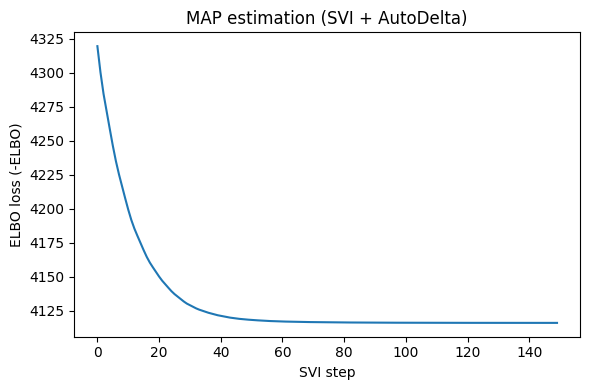

In [5]:
mu0, scale_tril, tau, alpha, beta = natural_params(opt_params)
print("Learned (MAP) hyperparameters")
print(f"  alpha = {float(alpha):+.3f}   beta = {float(beta):+.3f}  (lambda3 = {float(jnp.exp(beta)):.3f})")
print(f"  tau   = {np.round(np.asarray(tau), 3)}   (attack, defense drift)")
print(f"  Sigma0 diag = {np.round(np.diag(np.asarray(scale_tril @ scale_tril.T)), 3)}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(losses)
ax.set_xlabel("SVI step"); ax.set_ylabel("ELBO loss (-ELBO)")
ax.set_title("MAP estimation (SVI + AutoDelta)")
fig.tight_layout(); plt.show()

## 4. Filtering at the learned parameters: attack & defense ratings

Now let's do some prediction using these learned parameters! This takes the form of online filtering and prediction.


In [6]:
def world_cup_model(model, predict_times=None, predict_factor_indices=None):
    # record_filtered_states_mean also records the per-match local means + chol
    # covariances that section 5 reads.
    with Filter(filter_config=FactorialEKFConfig(record_filtered_states_mean=True)):
        dsx.sample(
            "skill",
            model,
            obs_times=obs_times,
            obs_values=obs_values,
            obs_factor_indices=obs_factor_indices,
            predict_times=predict_times,
            predict_factor_indices=predict_factor_indices,
        )


fitted_model = make_model(opt_params)
trace = Predictive(lambda: world_cup_model(fitted_model), num_samples=1)(
    jax.random.PRNGKey(0)
)
skills = np.asarray(trace["skill_filtered_states_mean"][0])  # (F, 2)
attack, defense = skills[:, 0], skills[:, 1]
overall = attack + defense

order = np.argsort(overall)[::-1]
ranking = pd.DataFrame(
    {
        "team": [wc_teams[i] for i in order],
        "attack": attack[order],
        "defense": defense[order],
        "overall": overall[order],
    }
)
ranking.index = np.arange(1, F + 1)
ranking.head(15).round(3)

,team,attack,defense,overall
1,Portugal,0.438,0.563,1.001
2,Argentina,0.350,0.615,0.964
3,France,0.452,0.462,0.914
4,Brazil,0.510,0.391,0.901
5,Spain,0.522,0.342,0.865
6,Belgium,0.485,0.304,0.789
7,England,0.288,0.403,0.691
8,Colombia,0.201,0.396,0.597
9,Netherlands,0.388,0.161,0.550
10,Japan,0.262,0.277,0.539


We can then visualize top teams:

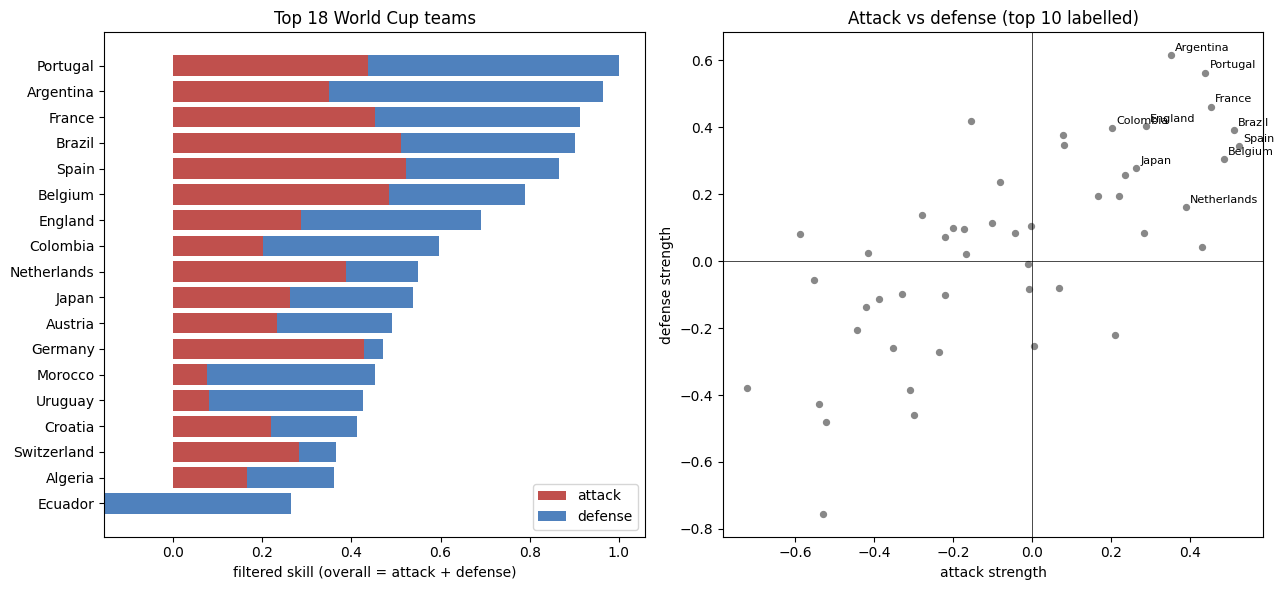

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
top = 18
to = order[:top][::-1]
ax = axes[0]
ax.barh([wc_teams[i] for i in to], attack[to], color="#c0504d", label="attack")
ax.barh([wc_teams[i] for i in to], defense[to], left=attack[to], color="#4f81bd", label="defense")
ax.set_xlabel("filtered skill (overall = attack + defense)")
ax.set_title(f"Top {top} World Cup teams"); ax.legend(loc="lower right")
ax = axes[1]
ax.scatter(attack, defense, s=18, color="#888")
for i in order[:10]:
    ax.annotate(wc_teams[i], (attack[i], defense[i]), fontsize=8, xytext=(3, 3), textcoords="offset points")
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("attack strength"); ax.set_ylabel("defense strength")
ax.set_title("Attack vs defense (top 10 labelled)")
fig.tight_layout(); plt.show()

## 5. Attack & defense trajectories with uncertainty

Since we're filtering, we can observe probabilistic estimates!

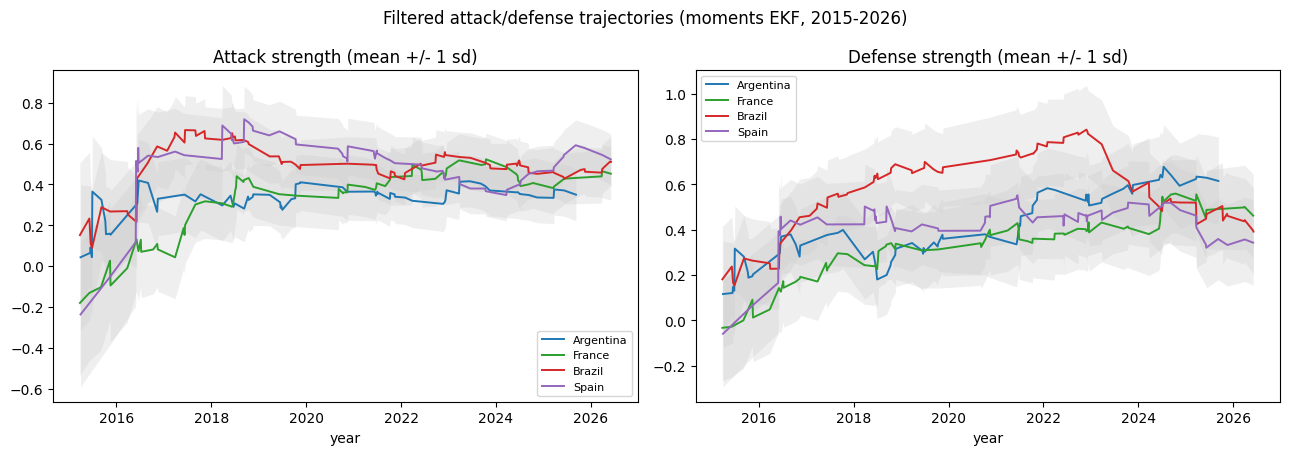

In [8]:
# Reuse the EKF filter pass (cell above): per-match local means + covariances.
local = np.asarray(trace["skill_filtered_local_states_mean"][0])  # (K, 2, 2) [slot][att, def]
chol = np.asarray(trace["skill_filtered_local_states_chol_cov"][0])  # (K, 2, 2, 2)
local_sd = np.sqrt(np.diagonal(chol @ np.swapaxes(chol, -1, -2), axis1=-2, axis2=-1))  # (K,2,2)
idx_np = np.asarray(obs_factor_indices)
match_dates = played["date"].to_numpy()

def team_trajectory(team):
    i = team_idx[team]; dt, at, df_, asd, dsd = [], [], [], [], []
    for k in range(K):
        for j in range(2):
            if idx_np[k, j] == i:
                dt.append(match_dates[k]); at.append(local[k, j, 0]); df_.append(local[k, j, 1])
                asd.append(local_sd[k, j, 0]); dsd.append(local_sd[k, j, 1])
    return np.array(dt), np.array(at), np.array(df_), np.array(asd), np.array(dsd)

teams_show = [t for t in ["Argentina", "France", "Brazil", "Spain"] if t in team_idx]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for team, color in zip(teams_show, ["#1f77b4", "#2ca02c", "#d62728", "#9467bd"]):
    dt, at, df_, asd, dsd = team_trajectory(team)
    axes[0].fill_between(dt, at - asd, at + asd, color="0.8", alpha=0.3, lw=0)
    axes[1].fill_between(dt, df_ - dsd, df_ + dsd, color="0.8", alpha=0.3, lw=0)
    axes[0].plot(dt, at, color=color, lw=1.4, label=team)
    axes[1].plot(dt, df_, color=color, lw=1.4, label=team)
axes[0].set_title("Attack strength (mean +/- 1 sd)"); axes[1].set_title("Defense strength (mean +/- 1 sd)")
for ax in axes:
    ax.set_xlabel("year"); ax.legend(fontsize=8)
fig.suptitle("Filtered attack/defense trajectories (moments EKF, 2015-2026)")
fig.tight_layout(); plt.show()

## 6. Predicting World Cup scorelines

We can also make concrete score predictions for World Cup games:

In [9]:
pred_dates = future["date"].to_numpy()
P = len(future)
predict_times = jnp.asarray(
    (future["date"] - t0_date).dt.days.to_numpy().astype(float) / 365.25 + np.arange(P) * 1e-6
)
predict_factor_indices = jnp.asarray(
    np.stack(
        [future["home_team"].map(team_idx).to_numpy(), future["away_team"].map(team_idx).to_numpy()],
        axis=1,
    ).astype(np.int32)
)

ptrace = Predictive(
    lambda: world_cup_model(fitted_model, predict_times, predict_factor_indices), num_samples=1
)(jax.random.PRNGKey(0))
pred_means = ptrace["skill_predicted_states"][0]
pred_chols = ptrace["skill_predicted_states_chol_cov"][0]

GRID = 6
score_grids, wdl = factorial_score_probabilities(
    fitted_model.observation_model, pred_means, pred_chols,
    key=jax.random.PRNGKey(1), n_samples=4000, max_goals_grid=GRID,
)
score_grids = np.asarray(score_grids); wdl = np.asarray(wdl)
exp_home = (score_grids.sum(2) * np.arange(GRID + 1)).sum(1)
exp_away = (score_grids.sum(1) * np.arange(GRID + 1)).sum(1)

predictions = pd.DataFrame(
    {
        "date": pd.to_datetime(pred_dates).strftime("%Y-%m-%d"),
        "home": future["home_team"].to_numpy(), "away": future["away_team"].to_numpy(),
        "P(home win)": wdl[:, 0], "P(draw)": wdl[:, 1], "P(away win)": wdl[:, 2],
        "exp_home_goals": exp_home, "exp_away_goals": exp_away,
    }
)
predictions.round(2).head(16)

,date,home,away,P(home win),P(draw),P(away win),exp_home_goals,exp_away_goals
0,2026-06-11,Mexico,South Africa,0.48,0.29,0.23,1.33,0.84
1,2026-06-11,South Korea,Czech Republic,0.49,0.25,0.26,1.59,1.09
2,2026-06-12,Canada,Bosnia and Herzegovina,0.49,0.28,0.23,1.44,0.90
3,2026-06-12,United States,Paraguay,0.38,0.30,0.32,1.18,1.06
4,2026-06-13,Qatar,Switzerland,0.11,0.15,0.74,0.92,2.54
5,2026-06-13,Brazil,Morocco,0.49,0.26,0.25,1.53,1.02
6,2026-06-13,Haiti,Scotland,0.20,0.24,0.56,0.92,1.75
7,2026-06-13,Australia,Turkey,0.38,0.24,0.37,1.52,1.49
8,2026-06-14,Sweden,Tunisia,0.34,0.26,0.40,1.28,1.40
9,2026-06-14,Netherlands,Japan,0.38,0.25,0.37,1.51,1.48


### Score-grid heatmaps for selected fixtures

We can visualize these scores in a type of heatmap.

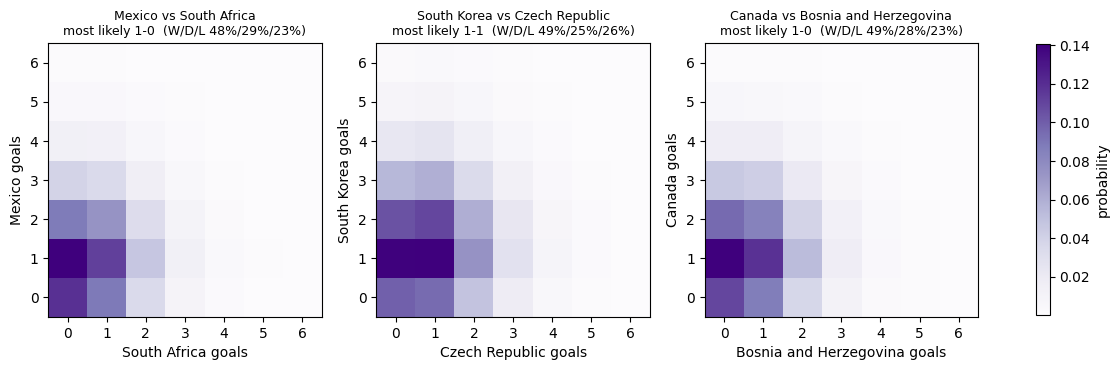

In [10]:
def show_fixture(ax, p):
    g = score_grids[p]
    im = ax.imshow(g, origin="lower", cmap="Purples")
    ax.set_xlabel(f"{future['away_team'].iloc[p]} goals")
    ax.set_ylabel(f"{future['home_team'].iloc[p]} goals")
    ax.set_xticks(range(GRID + 1)); ax.set_yticks(range(GRID + 1))
    best = np.unravel_index(np.argmax(g), g.shape)
    ax.set_title(
        f"{future['home_team'].iloc[p]} vs {future['away_team'].iloc[p]}\n"
        f"most likely {best[0]}-{best[1]}  (W/D/L {wdl[p,0]:.0%}/{wdl[p,1]:.0%}/{wdl[p,2]:.0%})",
        fontsize=9,
    )
    return im


n_show = min(3, P)
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 4.4))
axes = np.atleast_1d(axes)
for ax, p in zip(axes, range(n_show)):
    im = show_fixture(ax, p)
fig.colorbar(im, ax=list(axes), shrink=0.8, label="probability")
plt.show()

## 7. Online one-step-ahead performance

To get an idea of how well this works, we can use previous forecasted performance over existing international games. This is a bit cheating, since we used all data to fit our parameters. But this is all for good fun, so it's okay.

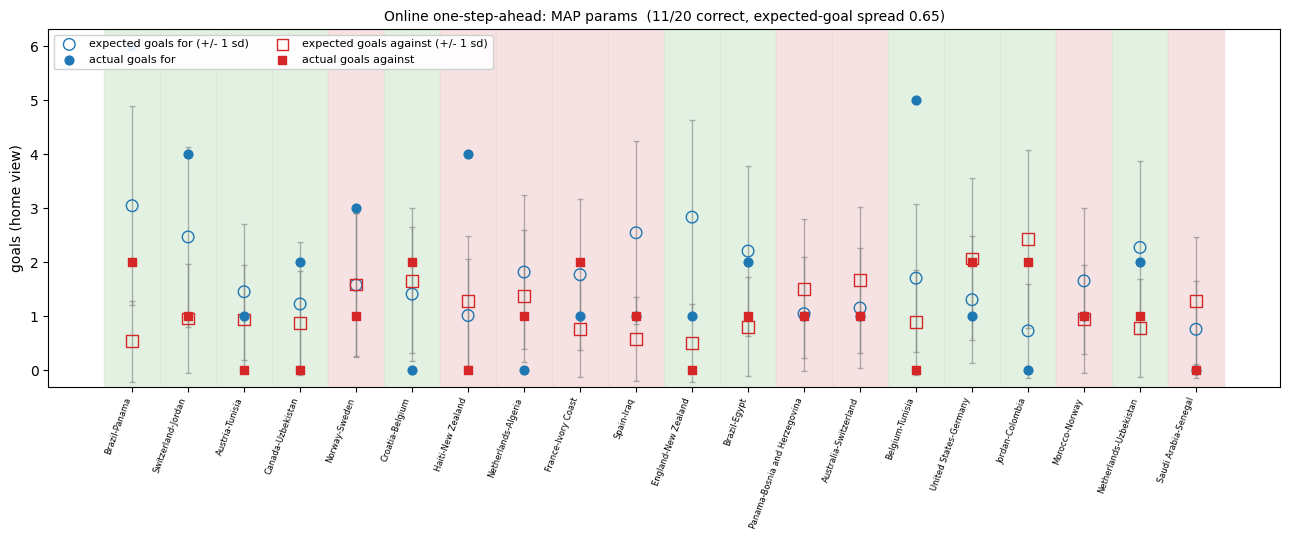

In [11]:
def online_eval(model, n_recent=20):
    """Causal one-step-ahead predictions for the last `n_recent` matches (moments EKF)."""
    def _prog():
        with Filter(filter_config=FactorialEKFConfig(record_filtered_states_mean=True)):
            dsx.sample("score", model, obs_times=obs_times, obs_values=obs_values,
                       obs_factor_indices=obs_factor_indices)

    _pr = Predictive(_prog, num_samples=1)(jax.random.PRNGKey(0))
    filt_mean = np.asarray(_pr["score_filtered_local_states_mean"][0])   # (K, 2, D)
    filt_chol = np.asarray(_pr["score_filtered_local_states_chol_cov"][0])  # (K, 2, D, D)
    idx = np.asarray(obs_factor_indices); tn = np.asarray(obs_times)
    mu0n = np.asarray(model.initial_condition.mean)
    Ln = np.asarray(model.initial_condition.scale_tril); prior_cov = Ln @ Ln.T
    taun = np.asarray(model.state_evolution.tau)

    def last_before(team, k):
        for kk in range(k - 1, -1, -1):
            for j in range(2):
                if idx[kk, j] == team:
                    return tn[kk], filt_mean[kk, j], filt_chol[kk, j] @ filt_chol[kk, j].T
        return 0.0, mu0n, prior_cov

    cut = K - n_recent
    pm, pc = [], []
    for k in range(cut, K):
        bm, bc = [], []
        for team in idx[k]:
            tp, mp, cp = last_before(int(team), k)
            cov = cp + np.diag(taun**2 * (tn[k] - tp))  # random-walk predict
            bm.append(mp); bc.append(np.linalg.cholesky(cov))
        pm.append(np.stack(bm)); pc.append(np.stack(bc))
    pm = jnp.asarray(np.stack(pm)); pc = jnp.asarray(np.stack(pc))

    grids, wdl_o = factorial_score_probabilities(
        model.observation_model, pm, pc, key=jax.random.PRNGKey(2), n_samples=4000, max_goals_grid=10
    )
    grids = np.asarray(grids); wdl_o = np.asarray(wdl_o); gv = np.arange(grids.shape[-1])
    exp_for = (grids.sum(2) * gv).sum(1); exp_against = (grids.sum(1) * gv).sum(1)
    std_for = np.sqrt(np.clip((grids.sum(2) * gv**2).sum(1) - exp_for**2, 0, None))
    std_against = np.sqrt(np.clip((grids.sum(1) * gv**2).sum(1) - exp_against**2, 0, None))
    pred_outcome = wdl_o.argmax(1)
    act = np.asarray(obs_values)[cut:K]; af, aa = act[:, 0], act[:, 1]
    actual_outcome = np.where(af > aa, 0, np.where(af == aa, 1, 2))
    correct = pred_outcome == actual_outcome
    labels = [f"{wc_teams[idx[k, 0]]}-{wc_teams[idx[k, 1]]}" for k in range(cut, K)]
    return dict(
        exp_for=exp_for, exp_against=exp_against, exp_for_std=std_for, exp_against_std=std_against,
        act_for=af, act_against=aa, correct=correct, labels=labels, n_recent=n_recent,
        n_correct=int(correct.sum()), mae_for=float(np.abs(exp_for - af).mean()),
        mae_against=float(np.abs(exp_against - aa).mean()), ef_std=float(exp_for.std()), ea_std=float(exp_against.std()),
    )


def plot_online(res, ax, title):
    n = res["n_recent"]; x = np.arange(n)
    for i in range(n):
        ax.axvspan(i - 0.5, i + 0.5, color="#d7ecd7" if res["correct"][i] else "#f3d7d7", alpha=0.7, zorder=0)
    ax.errorbar(x, res["exp_for"], yerr=res["exp_for_std"], fmt="none", ecolor="0.5", alpha=0.6, capsize=2, lw=1, zorder=1)
    ax.errorbar(x, res["exp_against"], yerr=res["exp_against_std"], fmt="none", ecolor="0.5", alpha=0.6, capsize=2, lw=1, zorder=1)
    ax.scatter(x, res["exp_for"], marker="o", facecolors="none", edgecolors="#1f77b4", s=70, zorder=2, label="expected goals for (+/- 1 sd)")
    ax.scatter(x, res["act_for"], marker="o", color="#1f77b4", s=40, zorder=3, label="actual goals for")
    ax.scatter(x, res["exp_against"], marker="s", facecolors="none", edgecolors="#d62728", s=70, zorder=2, label="expected goals against (+/- 1 sd)")
    ax.scatter(x, res["act_against"], marker="s", color="#d62728", s=40, zorder=3, label="actual goals against")
    ax.set_xticks(x); ax.set_xticklabels(res["labels"], rotation=70, ha="right", fontsize=6)
    ax.set_ylabel("goals (home view)"); ax.set_ylim(bottom=-0.3); ax.set_title(title, fontsize=10)


res_mle = online_eval(fitted_model)
fig, ax = plt.subplots(figsize=(13, 5.5))
plot_online(res_mle, ax, f"Online one-step-ahead: MAP params  "
                         f"({res_mle['n_correct']}/{res_mle['n_recent']} correct, "
                         f"expected-goal spread {res_mle['ef_std']:.2f})")
ax.legend(loc="upper left", fontsize=8, ncol=2, framealpha=0.9)
fig.tight_layout(); plt.show()

## 8. Comparing parameter-estimation methods

There are a few different ways we can think about doing parameter estimation --- here, we consider MAP, **variational inference** (a full Gaussian posterior via `AutoMultivariateNormal`, vs the MAP point), NUTS, and the quoted EM results of Duffield et al., to compare the forecasting skill of each.

> **Note:** NUTS is pretty slow here. Yay, Bayesian stats.

In [12]:
# (ii) Variational inference: a full Gaussian posterior over theta via SVI + AutoMultivariateNormal
# (the AutoDelta fit above returns only the MAP mode; this learns a mean + covariance). Same
# idiomatic model, Filter outside, warm-started at the MAP; we summarise with the posterior mean.
vi_guide = AutoMultivariateNormal(svi_model, init_loc_fn=init_to_value(values=opt_params))
with Filter(filter_config=FactorialEKFConfig()):
    vi_svi = SVI(svi_model, vi_guide, optax.adam(0.02), loss=Trace_ELBO())
    vi_result = vi_svi.run(jax.random.PRNGKey(1), N_STEPS, progress_bar=False)
vi_post = vi_guide.sample_posterior(jax.random.PRNGKey(2), vi_result.params, sample_shape=(400,))
vi_params = {k: vi_post[k].mean(0) for k in ["mu0", "log_chol_diag", "chol_offdiag", "log_tau", "alpha", "beta"]}
vi_fitted_model = make_model(vi_params)
_, vst, vtau, val, vbe = natural_params(vi_params)
print(f"VI (AutoMultivariateNormal) posterior mean: alpha={float(val):+.3f} beta={float(vbe):+.3f} "
      f"tau={np.round(np.asarray(vtau),3)} Sigma0diag={np.round(np.diag(np.asarray(vst@vst.T)),3)}")

VI (AutoMultivariateNormal) posterior mean: alpha=+0.213 beta=-2.597 tau=[0.046 0.087] Sigma0diag=[0.155 0.066]


In [13]:
# (iii) NUTS over the hyperparameters -- the idiomatic dynestyx way: a numpyro model that
# samples theta and calls dsx.sample inside `with Filter(FactorialEKFConfig)`. Because make_model
# uses t0=None, dsx.sample traces cleanly under NUTS (no compute_factorial_filter bypass needed).
# Each leapfrog step backprops through the (deterministic) moments-EKF marginal likelihood.

def nuts_program():
    p = {name: numpyro.sample(name, prior) for name, prior in PRIORS.items()}
    with Filter(filter_config=FactorialEKFConfig()):
        dsx.sample("score", make_model(p), obs_times=obs_times,
                   obs_values=obs_values, obs_factor_indices=obs_factor_indices)

init_vals = {k: opt_params[k] for k in ["mu0", "log_chol_diag", "chol_offdiag", "log_tau", "alpha", "beta"]}
mcmc = MCMC(
    NUTS(nuts_program, max_tree_depth=4, init_strategy=init_to_value(values=init_vals)),
    num_warmup=60, num_samples=60, progress_bar=False,
)
mcmc.run(jax.random.PRNGKey(7))
post = mcmc.get_samples()
nuts_params = {
    "mu0": post["mu0"].mean(0), "log_chol_diag": post["log_chol_diag"].mean(0),
    "chol_offdiag": post["chol_offdiag"].mean(0), "log_tau": post["log_tau"].mean(0),
    "alpha": post["alpha"].mean(), "beta": post["beta"].mean(),
}
nuts_fitted_model = make_model(nuts_params)
_, nst, ntau, nal, nbe = natural_params(nuts_params)
print(f"NUTS posterior mean: alpha={float(nal):+.3f} beta={float(nbe):+.3f} "
      f"tau={np.round(np.asarray(ntau),3)} Sigma0diag={np.round(np.diag(np.asarray(nst@nst.T)),3)}")

NUTS posterior mean: alpha=+1.024 beta=-2.568 tau=[0.054 0.083] Sigma0diag=[0.154 0.066]


In [14]:
# (iv) Duffield et al. values. Time is in years here, so tau = 0.05/sqrt(day)
# becomes 0.05 * sqrt(365.25) per sqrt(year).
mean_goals = float(np.asarray(obs_values).mean())
tau_dpr = 0.05 * np.sqrt(365.25)
dpr_params = {
    "mu0": jnp.zeros(2),
    "log_chol_diag": jnp.log(jnp.array([np.sqrt(0.5), np.sqrt(0.5)])),  # Sigma_0 = 0.5 I
    "chol_offdiag": jnp.zeros(1),
    "log_tau": jnp.log(jnp.array([tau_dpr, tau_dpr])),
    "alpha": jnp.array(np.log(mean_goals)),
    "beta": jnp.array(-2.3),  # lambda3 ~ 0.1 (small shared-goals correlation)
}
dpr_fitted_model = make_model(dpr_params)
print(f"Duffield et al.: alpha={np.log(mean_goals):+.3f} beta=-2.300 "
      f"tau={tau_dpr:.3f} Sigma0diag=[0.5 0.5]")

Duffield et al.: alpha=+0.251 beta=-2.300 tau=0.956 Sigma0diag=[0.5 0.5]


In [15]:
results = {
    "(i) MAP": res_mle,
    "(ii) VI posterior mean": online_eval(vi_fitted_model),
    "(iii) NUTS posterior mean": online_eval(nuts_fitted_model),
    "(iv) Duffield et al.": online_eval(dpr_fitted_model),
}
summary = pd.DataFrame(
    {
        name: {
            "outcomes correct (/20)": r["n_correct"],
            "goal MAE (for)": round(r["mae_for"], 2),
            "goal MAE (against)": round(r["mae_against"], 2),
            "expected-goal spread (std)": round(r["ef_std"], 3),
        }
        for name, r in results.items()
    }
).T
summary

,outcomes correct (/20),goal MAE (for),goal MAE (against),expected-goal spread (std)
(i) MAP,11.0,1.20,0.62,0.654
(ii) VI posterior mean,11.0,1.20,0.62,0.664
(iii) NUTS posterior mean,11.0,1.20,0.62,0.662
(iv) Duffield et al.,11.0,1.51,0.95,0.784


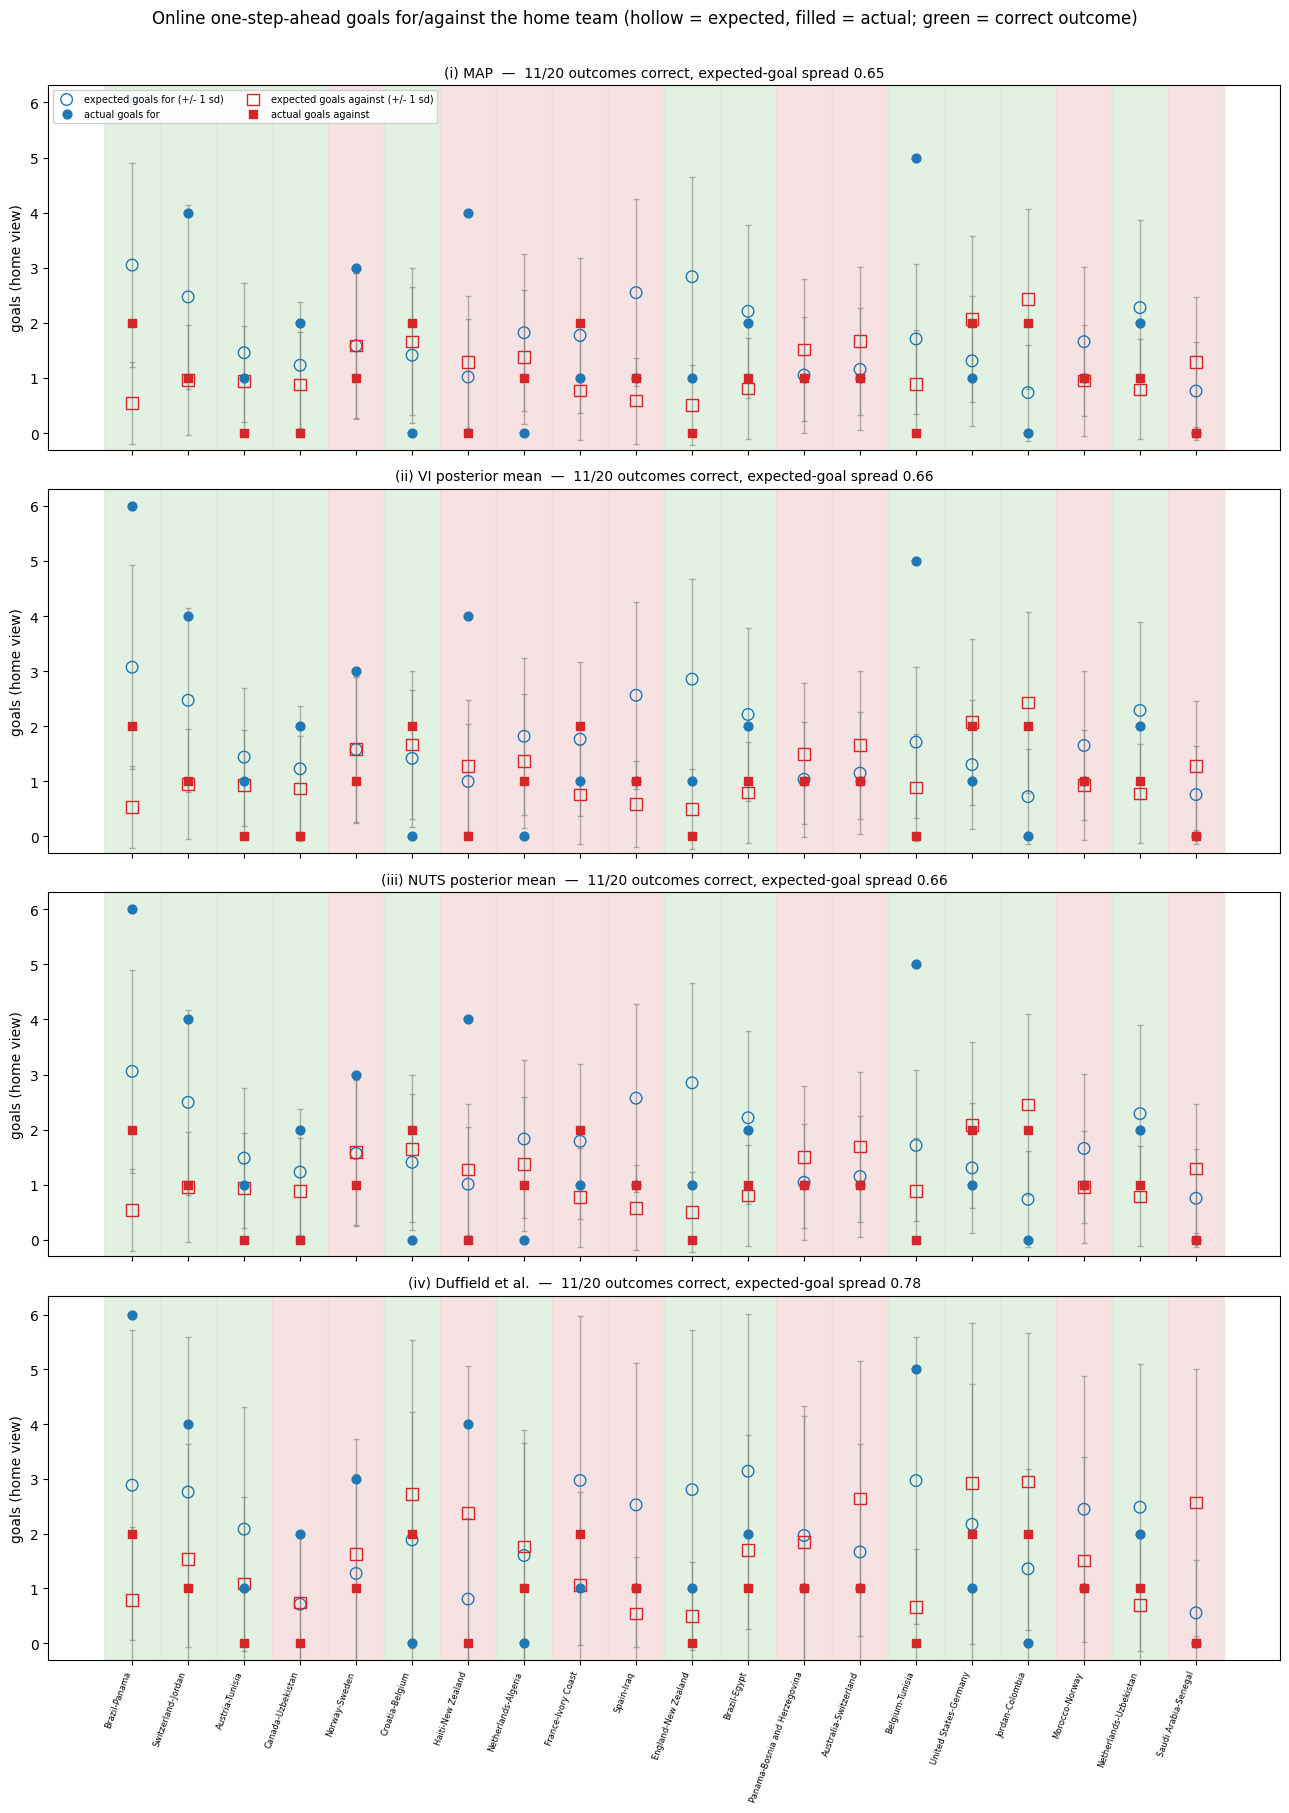

In [16]:
fig, axes = plt.subplots(4, 1, figsize=(13, 18), sharex=True)
for ax, (name, r) in zip(axes, results.items()):
    plot_online(r, ax, f"{name}  —  {r['n_correct']}/20 outcomes correct, "
                       f"expected-goal spread {r['ef_std']:.2f}")
axes[0].legend(loc="upper left", fontsize=7, ncol=2, framealpha=0.9)
fig.suptitle("Online one-step-ahead goals for/against the home team "
             "(hollow = expected, filled = actual; green = correct outcome)", y=1.005)
fig.tight_layout(); plt.show()

Overall, we have some positive signals towards the MAP/VI/NUTS-based inference here --- the variational posterior (`AutoMultivariateNormal`) lands right on top of NUTS at a fraction of the cost, and both track the MAP. Probably not enough reliable signal to crown a winner, but signal nonetheless.

## 9. Does more data — or more decisive dynamics — help?

We can also try to consider richer datasets. For example, give every World Cup team's full schedule (not just head-to-heads versus other World Cup teams). We can also fix some issues in the current data, like the fact that the "home team" in international matches is often not, in fact, at home, and that friendlies have a different incentive structure that can mess up our results.

We **fit** the full-schedule model's hyperparameters $\{\mu_0, \Sigma_0, \tau, \alpha, \beta, h, \text{friendly offset}\}$ by MAP (SVI + `AutoDelta`) — the same recipe as the head-to-head model, just over ~5k matches and ~200 teams, with a neutral-aware home advantage and a friendly offset via the controls $u=[\text{neutral}, \text{friendly}]$. The (deterministic) moments-EKF marginal likelihood stays cheap at this scale. We compare its out-of-sample scoreline NLL and outcome accuracy to the head-to-head model.

In [17]:
played_full = df.dropna(subset=["home_score", "away_score"]).copy()
played_full = played_full[
    (played_full["date"] >= "2015-01-01")
    & (played_full["home_team"].isin(team_idx) | played_full["away_team"].isin(team_idx))
].sort_values("date").reset_index(drop=True)
teams_full = sorted(set(played_full["home_team"]) | set(played_full["away_team"]))
tix_full = {t: i for i, t in enumerate(teams_full)}
Ff, Kf = len(teams_full), len(played_full)
t0f = played_full["date"].min()
daysf = (played_full["date"] - t0f).dt.days.to_numpy().astype(float)
otf = jnp.asarray(daysf / 365.25 + np.arange(Kf) * 1e-6)
oif = jnp.asarray(np.stack([played_full["home_team"].map(tix_full).to_numpy(),
                            played_full["away_team"].map(tix_full).to_numpy()], 1).astype(np.int32))
ovf = jnp.asarray(np.stack([played_full["home_score"].to_numpy(),
                            played_full["away_score"].to_numpy()], 1).astype(np.int32))
# Per-match controls u = [neutral, friendly].
ctrlf = jnp.asarray(np.stack([played_full["neutral"].to_numpy().astype(float),
                              (played_full["tournament"] == "Friendly").to_numpy().astype(float)], 1))
print(f"full schedules: {Ff} teams, {Kf} matches  (head-to-head was {F} teams, {K} matches)")

full schedules: 213 teams, 5075 matches  (head-to-head was 48 teams, 1318 matches)


In [18]:
# Dataset-parametrised causal online evaluation: one EKF pass, predictive NLL +
# accuracy + skill spread on `eval_pos` (using each factor's last pre-match state).
def online_eval_ds(model, ot, ov, oi, controls, eval_pos, team_names):
    def _prog():
        with Filter(filter_config=FactorialEKFConfig(record_filtered_states_mean=True)):
            dsx.sample("score", model, obs_times=ot, obs_values=ov,
                       obs_factor_indices=oi, obs_controls=controls)

    _pr = Predictive(_prog, num_samples=1)(jax.random.PRNGKey(0))
    fm = np.asarray(_pr["score_filtered_local_states_mean"][0])
    fc = np.asarray(_pr["score_filtered_local_states_chol_cov"][0])
    fb_final = np.asarray(_pr["score_filtered_states_mean"][0])
    idx = np.asarray(oi); tn = np.asarray(ot)
    taun = np.asarray(model.state_evolution.tau)
    Ln = np.asarray(model.initial_condition.scale_tril); pcov = Ln @ Ln.T
    mu0 = np.asarray(model.initial_condition.mean)

    def last_before(team, k):
        for kk in range(k - 1, -1, -1):
            for j in range(2):
                if idx[kk, j] == team:
                    return tn[kk], fm[kk, j], fc[kk, j] @ fc[kk, j].T
        return 0.0, mu0, pcov

    pm, pc = [], []
    for k in eval_pos:
        bm, bc = [], []
        for team in idx[k]:
            tp, mp, cp = last_before(int(team), k)
            cov = cp + np.diag(taun**2 * (tn[k] - tp))
            bm.append(mp); bc.append(np.linalg.cholesky(cov))
        pm.append(np.stack(bm)); pc.append(np.stack(bc))
    pm = jnp.asarray(np.stack(pm)); pc = jnp.asarray(np.stack(pc))
    cpos = controls[np.asarray(eval_pos)] if controls is not None else None
    grids, wdl_o = factorial_score_probabilities(
        model.observation_model, pm, pc, key=jax.random.PRNGKey(5),
        n_samples=2000, max_goals_grid=10, controls=cpos)
    grids = np.asarray(grids); wdl_o = np.asarray(wdl_o); gv = np.arange(grids.shape[-1])
    act = np.asarray(ov)[eval_pos]; af, aa = act[:, 0], act[:, 1]
    nll = -np.mean(np.log(np.clip(grids[np.arange(len(eval_pos)), af, aa], 1e-9, None)))
    po = wdl_o.argmax(1); aoc = np.where(af > aa, 0, np.where(af == aa, 1, 2))
    correct = po == aoc
    ef = (grids.sum(2) * gv).sum(1); ea = (grids.sum(1) * gv).sum(1)
    sf = np.sqrt(np.clip((grids.sum(2) * gv**2).sum(1) - ef**2, 0, None))
    sa = np.sqrt(np.clip((grids.sum(1) * gv**2).sum(1) - ea**2, 0, None))
    net = fb_final[:, 0] + fb_final[:, 1]
    labels = [f"{team_names[idx[k,0]]}-{team_names[idx[k,1]]}" for k in eval_pos]
    return dict(exp_for=ef, exp_against=ea, exp_for_std=sf, exp_against_std=sa,
                act_for=af, act_against=aa, correct=correct,
                labels=labels, n_recent=len(eval_pos), nll=float(nll),
                acc=float(correct.mean()), egoal_std=float(ef.std()), skill_std=float(net.std()))


wcset = set(team_idx)
test_h = list(range(K))[-100:]
bothwc_f = [k for k in range(Kf)
            if played_full["home_team"].iloc[k] in wcset and played_full["away_team"].iloc[k] in wcset]
test_f = bothwc_f[-100:]

# Fit the full-schedule model by MAP (SVI + AutoDelta) -- the same recipe as the H2H model, over
# ~5k matches / ~200 teams; the moments-EKF marginal likelihood stays cheap at this scale.
def make_model_full(p):
    cd = jnp.exp(p["log_chol_diag"])
    L = jnp.array([[cd[0], 0.0], [p["chol_offdiag"][0], cd[1]]])
    return FactorialDynamicalModel(
        initial_condition=dist.MultivariateNormal(p["mu0"], scale_tril=L),
        state_evolution=RandomWalkEvolution(tau=jnp.exp(p["log_tau"]), factor_state_dim=2),
        observation_model=BivariatePoissonScoreObservation(
            alpha=p["alpha"], beta=p["beta"], home_advantage=p["home_adv"],
            friendly_offset=p["friendly_off"], factor_state_dim=2, max_goals=MAX_GOALS),
        num_factors=Ff, num_local_factors=2, t0=None)

FULL_PRIORS = {
    "mu0": dist.Normal(0.0, 1.0).expand([2]).to_event(1),
    "log_chol_diag": dist.Normal(jnp.log(0.5), 0.7).expand([2]).to_event(1),
    "chol_offdiag": dist.Normal(0.0, 0.5).expand([1]).to_event(1),
    "log_tau": dist.Normal(jnp.log(0.2), 0.7).expand([2]).to_event(1),
    "alpha": dist.Normal(0.25, 0.5),
    "beta": dist.Normal(-2.3, 1.0),
    "home_adv": dist.Normal(0.2, 0.3),
    "friendly_off": dist.Normal(0.0, 0.3),
}

def full_svi_model():
    p = {name: numpyro.sample(name, prior) for name, prior in FULL_PRIORS.items()}
    dsx.sample("score", make_model_full(p), obs_times=otf, obs_values=ovf,
               obs_factor_indices=oif, obs_controls=ctrlf)

full_init = {"mu0": jnp.zeros(2), "log_chol_diag": jnp.log(jnp.array([0.4, 0.4])),
             "chol_offdiag": jnp.zeros(1), "log_tau": jnp.log(jnp.array([0.15, 0.15])),
             "alpha": jnp.array(float(np.log(np.asarray(ovf).mean()))), "beta": jnp.array(-2.3),
             "home_adv": jnp.array(0.2), "friendly_off": jnp.array(0.0)}
with Filter(filter_config=FactorialEKFConfig()):
    full_guide = AutoDelta(full_svi_model, init_loc_fn=init_to_value(values=full_init))
    full_svi = SVI(full_svi_model, full_guide, optax.adam(0.05), loss=Trace_ELBO())
    full_result = full_svi.run(jax.random.PRNGKey(0), 120, progress_bar=False)
full_params = {k: jnp.asarray(v) for k, v in full_guide.median(full_result.params).items()}
improved_model = make_model_full(full_params)
print(f"Full-schedule MAP fit (SVI+AutoDelta, EKF): alpha={float(full_params['alpha']):+.3f}, "
      f"beta={float(full_params['beta']):+.3f}, home_adv={float(full_params['home_adv']):+.3f}, "
      f"friendly_off={float(full_params['friendly_off']):+.3f}, "
      f"tau={np.round(np.exp(np.asarray(full_params['log_tau'])),3)}")

r_orig = online_eval_ds(fitted_model, obs_times, obs_values, obs_factor_indices, None, test_h, wc_teams)
r_impr = online_eval_ds(improved_model, otf, ovf, oif, ctrlf, test_f, teams_full)
comparison = pd.DataFrame({
    "head-to-head (MAP fit)": {
        "out-of-sample NLL/match": round(r_orig["nll"], 3), "outcome accuracy": round(r_orig["acc"], 3),
        "expected-goal spread": round(r_orig["egoal_std"], 3), "skill spread": round(r_orig["skill_std"], 3)},
    "full schedules (SVI-MAP fit)": {
        "out-of-sample NLL/match": round(r_impr["nll"], 3), "outcome accuracy": round(r_impr["acc"], 3),
        "expected-goal spread": round(r_impr["egoal_std"], 3), "skill spread": round(r_impr["skill_std"], 3)},
}).T
comparison

Full-schedule MAP fit (SVI+AutoDelta, EKF): alpha=+0.211, beta=-3.177, home_adv=+0.307, friendly_off=-0.030, tau=[0.062 0.075]


,out-of-sample NLL/match,outcome accuracy,expected-goal spread,skill spread
head-to-head (MAP fit),2.848,0.52,0.559,0.585
full schedules (SVI-MAP fit),2.832,0.51,0.575,1.253


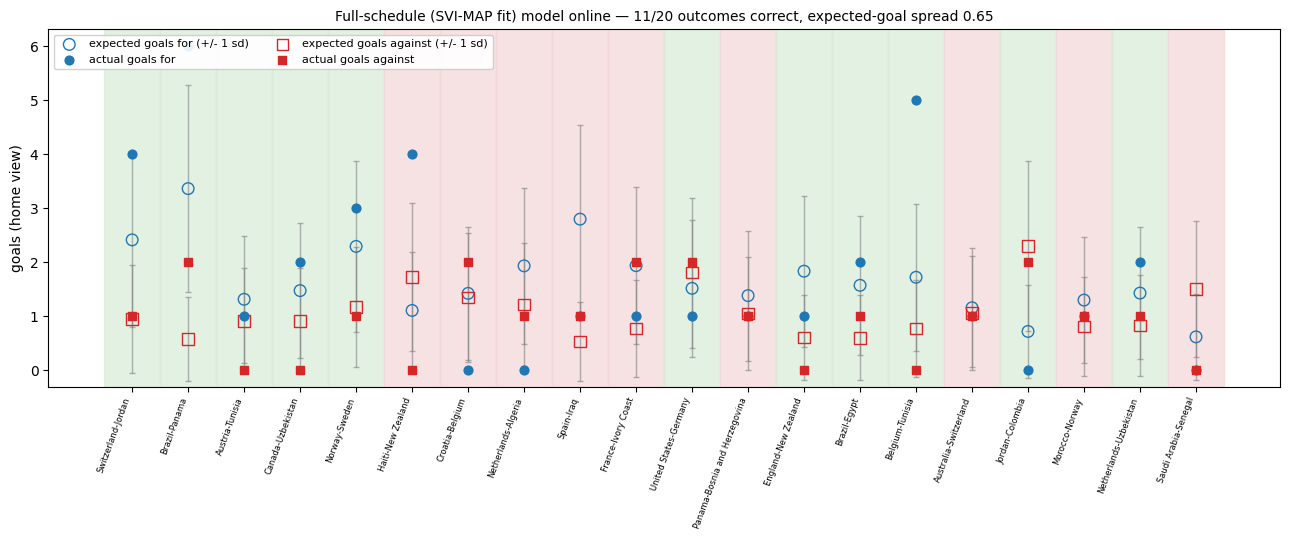

In [19]:
res_impr20 = online_eval_ds(improved_model, otf, ovf, oif, ctrlf, test_f[-20:], teams_full)
ncorr = int(res_impr20["correct"].sum())
fig, ax = plt.subplots(figsize=(13, 5.5))
plot_online(res_impr20, ax,
            f"Full-schedule (SVI-MAP fit) model online — "
            f"{ncorr}/20 outcomes correct, expected-goal spread {res_impr20['egoal_std']:.2f}")
ax.legend(loc="upper left", fontsize=8, ncol=2, framealpha=0.9)
fig.tight_layout(); plt.show()

## 10. A richer observation model: overdispersion, home advantage, and friendlies

The §9 levers (a home-advantage term, a friendly flag) and **overdispersion** are properties of the *observation model*, not the dynamics or the dataset — so we can fold all three into the **head-to-head** model directly. We swap the bivariate-Poisson likelihood for the overdispersed **bivariate negative binomial** (`BivariateNegativeBinomialScoreObservation` — independent NB margins with a learned dispersion $r$, recovering the Poisson as $r\to\infty$), and turn on a **neutral-aware home advantage** $h$ and a **friendly offset** through the per-match controls $u = [\text{neutral}, \text{friendly}]$ (the home edge is scaled by $1-\text{neutral}$, so the neutral 2026 fixtures get none; the baseline rate shifts by $\text{offset}\cdot\text{friendly}$). We fit the new hyperparameters $\{\mu_0, \Sigma_0, \tau, \alpha, h, \text{offset}, \log r\}$ by the same MAP (SVI + `AutoDelta`) and compare the online accuracy / scoreline NLL against the plain Poisson baseline on the same held-out matches.

In [20]:
# Per-match controls u = [neutral, friendly] for the head-to-head matches.
ctrl_h2h = jnp.asarray(np.stack([
    played["neutral"].to_numpy().astype(float),
    (played["tournament"] == "Friendly").to_numpy().astype(float),
], axis=1))
print(f"{int(ctrl_h2h[:, 0].sum())} neutral-venue and {int(ctrl_h2h[:, 1].sum())} friendly matches "
      f"of {K} head-to-head games")

ENH_PRIORS = {
    "mu0": dist.Normal(0.0, 1.0).expand([2]).to_event(1),
    "log_chol_diag": dist.Normal(jnp.log(0.5), 0.7).expand([2]).to_event(1),
    "chol_offdiag": dist.Normal(0.0, 0.5).expand([1]).to_event(1),
    "log_tau": dist.Normal(jnp.log(0.4), 0.7).expand([2]).to_event(1),
    "alpha": dist.Normal(0.25, 0.5),
    "home_adv": dist.Normal(0.1, 0.3),
    "friendly_off": dist.Normal(0.0, 0.3),
    "log_dispersion": dist.Normal(jnp.log(10.0), 1.0),
}

def make_model_enh(p):
    cd = jnp.exp(p["log_chol_diag"])
    L = jnp.array([[cd[0], 0.0], [p["chol_offdiag"][0], cd[1]]])
    return FactorialDynamicalModel(
        initial_condition=dist.MultivariateNormal(p["mu0"], scale_tril=L),
        state_evolution=RandomWalkEvolution(tau=jnp.exp(p["log_tau"]), factor_state_dim=D),
        observation_model=BivariateNegativeBinomialScoreObservation(
            alpha=p["alpha"], home_advantage=p["home_adv"], friendly_offset=p["friendly_off"],
            log_dispersion=p["log_dispersion"], factor_state_dim=D),
        num_factors=F, num_local_factors=2, t0=None)

def enh_svi_model():
    p = {name: numpyro.sample(name, prior) for name, prior in ENH_PRIORS.items()}
    dsx.sample("score", make_model_enh(p), obs_times=obs_times, obs_values=obs_values,
               obs_factor_indices=obs_factor_indices, obs_controls=ctrl_h2h)

enh_init = {"mu0": jnp.zeros(2), "log_chol_diag": jnp.log(jnp.array([0.5, 0.5])),
            "chol_offdiag": jnp.zeros(1), "log_tau": jnp.log(jnp.array([0.4, 0.4])),
            "alpha": jnp.array(0.25), "home_adv": jnp.array(0.1), "friendly_off": jnp.array(0.0),
            "log_dispersion": jnp.log(jnp.array(10.0))}
with Filter(filter_config=FactorialEKFConfig()):
    enh_guide = AutoDelta(enh_svi_model, init_loc_fn=init_to_value(values=enh_init))
    enh_svi = SVI(enh_svi_model, enh_guide, optax.adam(0.05), loss=Trace_ELBO())
    enh_result = enh_svi.run(jax.random.PRNGKey(0), N_STEPS, progress_bar=False)
enh_params = {k: jnp.asarray(v) for k, v in enh_guide.median(enh_result.params).items()}
enh_fitted_model = make_model_enh(enh_params)
print(f"Enhanced (NB + home + friendly) MAP fit: alpha={float(enh_params['alpha']):+.3f}, "
      f"home_adv={float(enh_params['home_adv']):+.3f}, friendly_off={float(enh_params['friendly_off']):+.3f}, "
      f"dispersion r={float(jnp.exp(enh_params['log_dispersion'])):.1f} "
      f"(variance/mean at lambda=1.3: {float(1 + 1.3 / jnp.exp(enh_params['log_dispersion'])):.2f})")

476 neutral-venue and 518 friendly matches of 1318 head-to-head games


Enhanced (NB + home + friendly) MAP fit: alpha=+0.229, home_adv=+0.203, friendly_off=+0.048, dispersion r=40.8 (variance/mean at lambda=1.3: 1.03)


In [21]:
# Repeat the online accuracy / scoreline-NLL comparison: Poisson baseline vs the enhanced model.
r_pois = online_eval_ds(fitted_model, obs_times, obs_values, obs_factor_indices, None, test_h, wc_teams)
r_enh = online_eval_ds(enh_fitted_model, obs_times, obs_values, obs_factor_indices, ctrl_h2h, test_h, wc_teams)
pd.DataFrame({
    "Bivariate Poisson (baseline)": {
        "out-of-sample NLL/match": round(r_pois["nll"], 3), "outcome accuracy": round(r_pois["acc"], 3),
        "expected-goal spread": round(r_pois["egoal_std"], 3)},
    "NB + home adv + friendly": {
        "out-of-sample NLL/match": round(r_enh["nll"], 3), "outcome accuracy": round(r_enh["acc"], 3),
        "expected-goal spread": round(r_enh["egoal_std"], 3)},
}).T

,out-of-sample NLL/match,outcome accuracy,expected-goal spread
Bivariate Poisson (baseline),2.848,0.52,0.559
NB + home adv + friendly,2.848,0.49,0.610


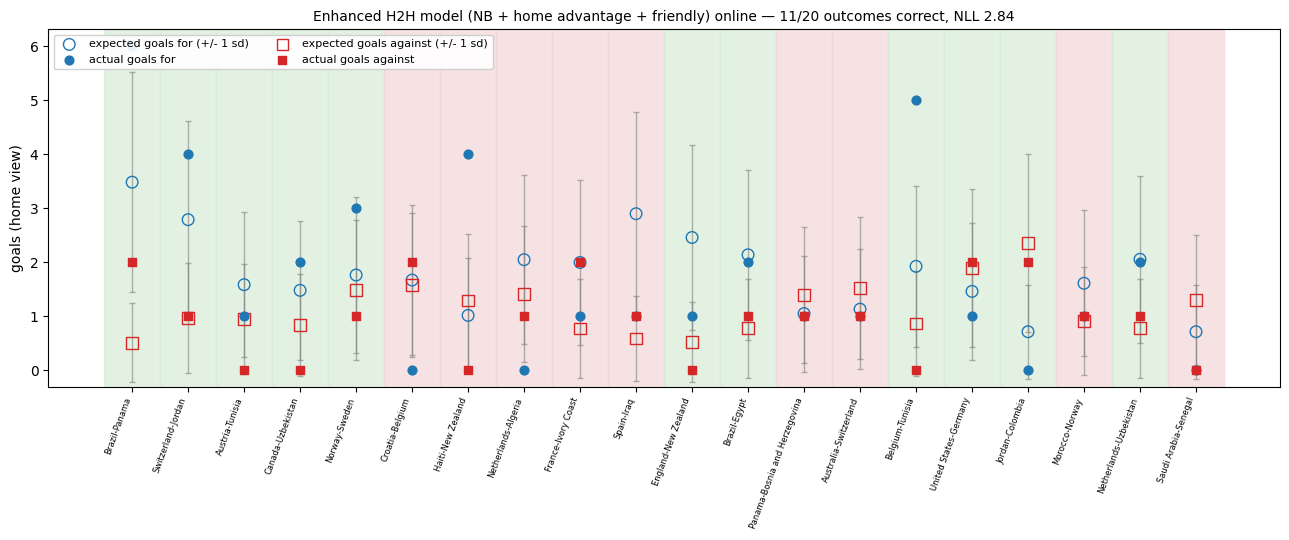

In [22]:
# Online one-step-ahead for the enhanced model on the last 20 head-to-head matches.
r_enh20 = online_eval_ds(enh_fitted_model, obs_times, obs_values, obs_factor_indices,
                         ctrl_h2h, list(range(K))[-20:], wc_teams)
fig, ax = plt.subplots(figsize=(13, 5.5))
plot_online(r_enh20, ax, f"Enhanced H2H model (NB + home advantage + friendly) online — "
                         f"{int(r_enh20['correct'].sum())}/20 outcomes correct, NLL {r_enh20['nll']:.2f}")
ax.legend(loc="upper left", fontsize=8, ncol=2, framealpha=0.9)
fig.tight_layout(); plt.show()

**Result.** All three additions are *principled* but barely move the held-out numbers here. The learned **dispersion is large** ($r \approx 41$, variance/mean $\approx 1.03$): international goal counts are essentially Poisson, so the negative binomial collapses onto it — there is no overdispersion to exploit (the same story as the EPL scoreline model). The model *does* learn a **sizeable home advantage** ($h \approx 0.20$) and a small friendly offset, but neither helps the one-step-ahead test: the held-out matches mix neutral-venue tournaments (where $h$ is switched off) with home games, and the 2026 fixtures are all neutral, so the home term largely washes out of the forecast. Net: the scoreline NLL is unchanged (2.848 vs 2.848) and outcome accuracy is a touch *lower* (0.49 vs 0.52) — the extra parameters add flexibility the sparse, evenly-matched, largely-neutral data does not reward. As in §9, the richer observation model is a reusable capability (overdispersion, home advantage, friendlies all drop into the same `FactorialDynamicalModel`), but on this task the plain bivariate Poisson is already as good.